In [3]:
!pip install pandas

In [4]:
import pandas as pd
from datetime import datetime, timedelta, UTC
import matplotlib.pyplot as plt
import numpy as np

df= pd.read_csv('/content/HR_Job_Placement_Dataset.csv')
df

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,27,Male,65.061656,83.842578,75.856526,Computer Science,58.221909,89.566305,64.474484,79.548913,...,5.805850,Tier 3,Not Matched,Medium,Not Required,15.0,No,18.0,Not Willing,Not Placed
1,24,Male,67.885626,64.973305,73.093588,Electronics,71.927978,54.591971,61.077306,73.316134,...,10.807739,Tier 1,Matched,High,Required,0.0,NaN,NaN,Not Willing,Not Placed
2,33,Female,73.892471,68.834121,90.196460,Information Technology,72.445041,58.587088,79.494739,75.466980,...,5.476839,Tier 3,Not Matched,Low,Not Required,0.0,No,3.0,Not Willing,Placed
3,31,Male,74.145568,76.255126,75.586731,Mechanical,78.855676,61.022065,53.740386,73.676449,...,9.980580,Tier 2,Matched,Low,Not Required,0.0,Yes,6.0,NaN,Not Placed
4,28,Male,60.475937,65.786336,80.801010,Information Technology,68.286776,65.713731,61.438314,88.994847,...,8.921233,Tier 2,Matched,Medium,Not Required,0.0,No,3.0,Willing,Not Placed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51495,24,Female,65.747180,72.063946,72.247881,Electronics,55.923057,73.208032,69.108895,63.992488,...,6.315211,Tier 1,Matched,Low,Required,0.0,No,3.0,NaN,Not Placed
51496,22,Male,61.921459,66.729203,55.000000,Others,69.525121,70.245612,54.959868,88.514232,...,8.655391,Tier 1,Matched,Medium,Not Required,60.0,No,0.0,Not Willing,Placed
51497,30,Male,75.578202,75.717623,75.048301,Information Technology,73.073239,58.870416,71.219454,79.326789,...,11.538547,Tier 1,Matched,High,Not Required,0.0,No,12.0,NaN,Placed
51498,29,Female,77.327209,56.629227,69.735374,Mechanical,48.270078,61.171900,71.650243,76.318681,...,9.617279,Tier 2,Matched,Medium,Not Required,0.0,Yes,0.0,Willing,Not Placed


In [3]:
#df.describe()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51500 entries, 0 to 51499
Data columns (total 26 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   age_years                  51500 non-null  int64  
 1   gender                     51500 non-null  object 
 2   ssc_percentage             48919 non-null  float64
 3   hsc_percentage             49435 non-null  float64
 4   degree_percentage          51500 non-null  float64
 5   degree_specialization      51500 non-null  object 
 6   technical_score            51500 non-null  float64
 7   aptitude_score             51500 non-null  float64
 8   communication_score        51500 non-null  float64
 9   skills_match_percentage    51500 non-null  float64
 10  certifications_count       51500 non-null  int64  
 11  internship_experience      51500 non-null  object 
 12  years_of_experience        51500 non-null  int64  
 13  career_switch_willingness  43034 non-null  obj

**Data Cleaning Process**
1. Finding the missing values.

In [31]:
missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)
df

Missing Values:
age_years                                       0
ssc_percentage                                  0
hsc_percentage                                  0
degree_percentage                               0
technical_score                                 0
aptitude_score                                  0
communication_score                             0
skills_match_percentage                         0
certifications_count                            0
internship_experience                           0
years_of_experience                             0
career_switch_willingness                       0
relevant_experience                             0
previous_ctc_lpa                                0
expected_ctc_lpa                                0
competition_level                               0
bond_requirement                                0
notice_period_days                              0
layoff_history                                  0
employment_gap_months             

,age_years,ssc_percentage,hsc_percentage,degree_percentage,technical_score,aptitude_score,communication_score,skills_match_percentage,certifications_count,internship_experience,...,degree_specialization_Information Technology,degree_specialization_Mechanical,degree_specialization_Others,company_tier_Tier 1,company_tier_Tier 2,company_tier_Tier 2,company_tier_Tier 3,company_tier_Tier 3,job_role_match_Not Matched,experience_category
1,24,67.885626,64.973305,73.093588,71.927978,54.591971,61.077306,73.316134,1,yes,...,False,False,False,False,False,False,False,False,False,Fresher
2,33,73.892471,68.834121,90.196460,72.445041,58.587088,79.494739,75.466980,1,Yes,...,True,False,False,False,False,False,True,False,True,Junior
3,31,74.145568,76.255126,75.586731,78.855676,61.022065,53.740386,73.676449,2,No,...,False,True,False,False,True,False,False,False,False,Fresher
4,28,60.475937,65.786336,80.801010,68.286776,65.713731,61.438314,88.994847,1,No,...,True,False,False,False,True,False,False,False,False,Fresher
5,33,60.641768,66.151843,78.203455,85.063940,46.293090,47.638858,78.307411,1,Yes,...,False,False,True,False,True,False,False,False,True,Junior
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51493,25,62.551225,87.770434,75.760378,75.499660,57.339417,80.125196,89.676590,1,No,...,False,False,True,False,True,False,False,False,False,Junior
51494,26,69.562323,63.891266,75.931809,59.990409,51.169120,73.769113,68.913006,2,Yes,...,False,False,False,False,True,False,False,False,False,Fresher
51495,24,65.747180,72.063946,72.247881,55.923057,73.208032,69.108895,63.992488,2,No,...,False,False,False,False,False,False,False,False,False,Fresher
51498,29,77.327209,56.629227,69.735374,48.270078,61.171900,71.650243,76.318681,0,Yes,...,False,True,False,False,True,False,False,False,False,Fresher


2.Handling of Numerical and categorical data.

In [6]:
import pandas as pd
import numpy as np


# 1. Handle Numerical Columns (Median)
numeric_cols_to_fix = [
    'ssc_percentage',
    'hsc_percentage',
    'employment_gap_months',
    'notice_period_days'
]

for col in numeric_cols_to_fix:
    df[col] = df[col].fillna(df[col].median())

# 2. Handle Binary Willingness & History (Constant 'No')
boolean_cols = ['career_switch_willingness', 'relocation_willingness', 'layoff_history']
for col in boolean_cols:
    df[col] = df[col].fillna('No')

# 3. Handle Experience (Assume 0 if missing)
df['relevant_experience'] = df['relevant_experience'].fillna(0)

# 4. Handle Categorical Job Role Match (Mode)
# Using mode()[0] to get the most frequent string value
if not df['job_role_match'].mode().empty:
    df['job_role_match'] = df['job_role_match'].fillna(df['job_role_match'].mode()[0])

# Final Verification
print("Missing Values after final cleaning:")
print(df.isnull().sum())

Missing Values after final cleaning:
age_years                    0
gender                       0
ssc_percentage               0
hsc_percentage               0
degree_percentage            0
degree_specialization        0
technical_score              0
aptitude_score               0
communication_score          0
skills_match_percentage      0
certifications_count         0
internship_experience        0
years_of_experience          0
career_switch_willingness    0
relevant_experience          0
previous_ctc_lpa             0
expected_ctc_lpa             0
company_tier                 0
job_role_match               0
competition_level            0
bond_requirement             0
notice_period_days           0
layoff_history               0
employment_gap_months        0
relocation_willingness       0
status                       0
dtype: int64


3. Handling Outliers:

In [17]:
import numpy as np

# Dynamically select only numeric columns for outlier handling
numeric_features = df.select_dtypes(include=np.number).columns

# Outlier handling
Q1 = df[numeric_features].quantile(0.25)
Q3 = df[numeric_features].quantile(0.75)
IQR = Q3 - Q1

# Filter out rows where any numeric feature has an outlier
df = df[~((df[numeric_features] < (Q1 - 1.5 * IQR)) |
          (df[numeric_features] > (Q3 + 1.5 * IQR))).any(axis=1)]
print("Shape after outlier removal:", df.shape)


Shape after outlier removal: (39534, 26)


4. Understanding the output features of my dataset and Plotting it.

In [21]:
df['status'].value_counts()

,count
status,
Not Placed,26987
Placed,12547


/tmp/ipykernel_6884/666413091.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')


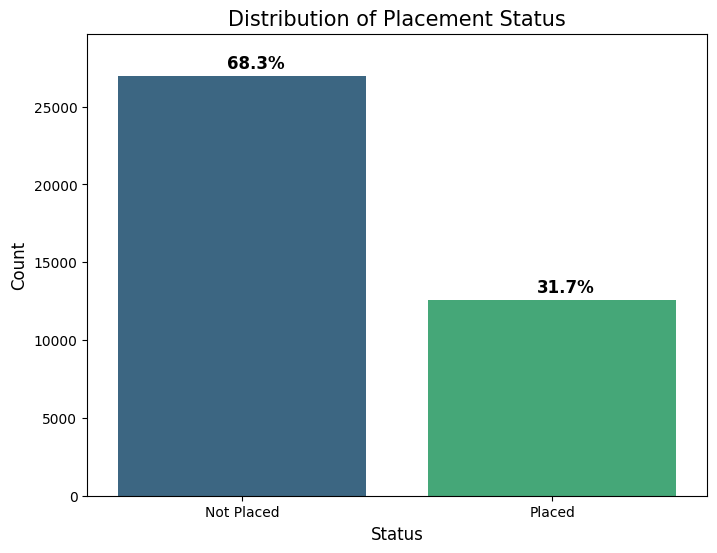

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Prepare the data
status_counts = df['status'].value_counts()
total = len(df)

# 2. Create the plot
plt.figure(figsize=(8, 6))
ax = sns.barplot(x=status_counts.index, y=status_counts.values, palette='viridis')

# 3. Add the percentage labels on top of each bar
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height() / total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height() + 500  # Offset to put text above the bar
    ax.annotate(percentage, (x, y), size=12, fontweight='bold')

# 4. Final touches
plt.title('Distribution of Placement Status', fontsize=15)
plt.xlabel('Status', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.ylim(0, max(status_counts.values) * 1.1) # Add some space for labels
plt.show()

In [25]:
# Saving the cleaned data
df.to_csv('JAPS_cleaned_data.csv', index=False)

Importing required librarys:

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

5. Data Encoding.

In [24]:
from sklearn.preprocessing import LabelEncoder

# 2. Encoding Target Variable (Status)
# Placed = 1, Not Placed = 0
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])

# 3. One-Hot Encoding for Categorical features
# Filter out columns that are no longer in df (e.g., if already one-hot encoded)
categorical_cols_to_encode = ['gender', 'degree_specialization', 'company_tier', 'job_role_match']
categorical_cols_to_encode_existing = [col for col in categorical_cols_to_encode if col in df.columns]
df = pd.get_dummies(df, columns=categorical_cols_to_encode_existing, drop_first=True)

# --- FINAL VERIFICATION ---
print("Data Shape after Preprocessing:", df.shape)
print(df.head())

Data Shape after Preprocessing: (39534, 35)
   age_years  ssc_percentage  hsc_percentage  degree_percentage  \
1         24       67.885626       64.973305          73.093588   
2         33       73.892471       68.834121          90.196460   
3         31       74.145568       76.255126          75.586731   
4         28       60.475937       65.786336          80.801010   
5         33       60.641768       66.151843          78.203455   

   technical_score  aptitude_score  communication_score  \
1        71.927978       54.591971            61.077306   
2        72.445041       58.587088            79.494739   
3        78.855676       61.022065            53.740386   
4        68.286776       65.713731            61.438314   
5        85.063940       46.293090            47.638858   

   skills_match_percentage  certifications_count internship_experience  ...  \
1                73.316134                     1                  yes   ...   
2                75.466980              

In [25]:
df.columns

Index(['age_years', 'ssc_percentage', 'hsc_percentage', 'degree_percentage',
       'technical_score', 'aptitude_score', 'communication_score',
       'skills_match_percentage', 'certifications_count',
       'internship_experience', 'years_of_experience',
       'career_switch_willingness', 'relevant_experience', 'previous_ctc_lpa',
       'expected_ctc_lpa', 'competition_level', 'bond_requirement',
       'notice_period_days', 'layoff_history', 'employment_gap_months',
       'relocation_willingness', 'status', 'gender_Male', 'gender_female',
       'gender_male', 'degree_specialization_Electronics',
       'degree_specialization_Information Technology',
       'degree_specialization_Mechanical', 'degree_specialization_Others',
       'company_tier_Tier 1 ', 'company_tier_Tier 2', 'company_tier_Tier 2 ',
       'company_tier_Tier 3', 'company_tier_Tier 3 ',
       'job_role_match_Not Matched'],
      dtype='object')

In [28]:
df.shape

(39534, 35)

Step 6 : Feature Engineering

/tmp/ipykernel_6884/361432814.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='status', y='technical_score', data=df, palette='Set2')
/tmp/ipykernel_6884/361432814.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='status', y='skills_match_percentage', data=df, palette='Pastel1')


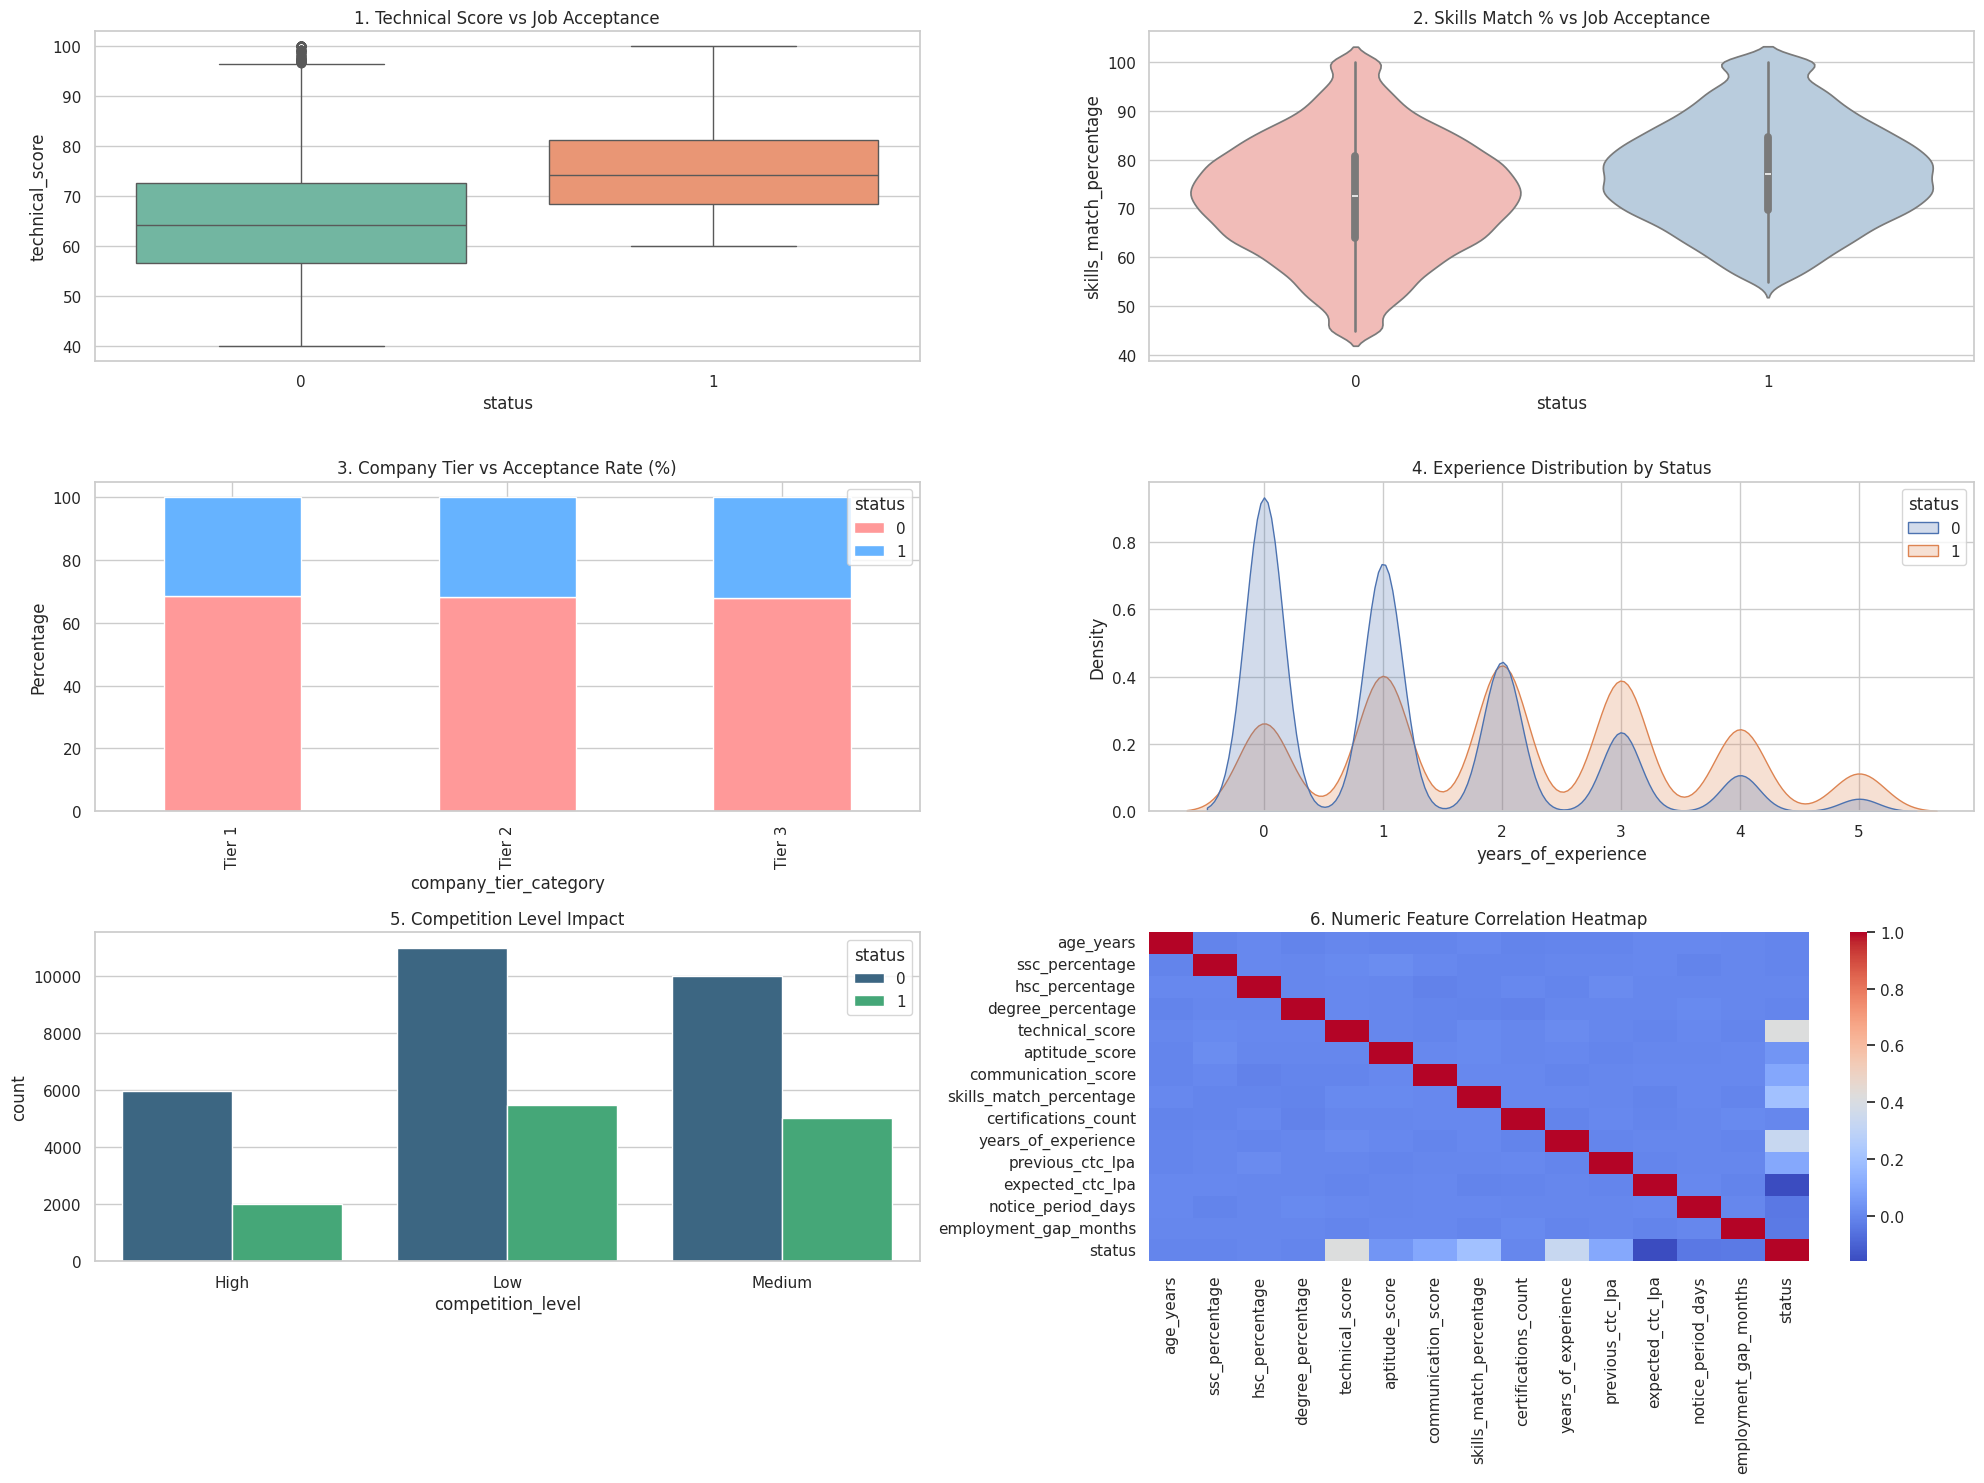

In [30]:
# Feature Engineering: Experience Category
def get_exp_category(exp):
    if exp == 0: return 'Fresher'
    elif exp <= 3: return 'Junior'
    else: return 'Senior'

df['experience_category'] = df['years_of_experience'].apply(get_exp_category)

# EDA Visualization: Interview Score vs Placement
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(20, 15))

# 1. Interview Score (Technical Score) vs Job Acceptance
plt.subplot(3, 2, 1)
sns.boxplot(x='status', y='technical_score', data=df, palette='Set2')
plt.title('1. Technical Score vs Job Acceptance')

# 2. Skills Match Percentage Impact
plt.subplot(3, 2, 2)
sns.violinplot(x='status', y='skills_match_percentage', data=df, palette='Pastel1')
plt.title('2. Skills Match % vs Job Acceptance')

# 3. Company Tier vs Acceptance Rate
plt.subplot(3, 2, 3)
# Creating a cross-tabulation for percentage-based visualization
# FIX: 'company_tier' column was one-hot encoded and no longer exists.
# Reconstruct it for plotting purposes.
df_plot_tier = df.copy()
# Assuming 'company_tier_Tier 1' was dropped due to drop_first=True in get_dummies
df_plot_tier['company_tier_category'] = ''
df_plot_tier.loc[df_plot_tier['company_tier_Tier 2'] == True, 'company_tier_category'] = 'Tier 2'
df_plot_tier.loc[df_plot_tier['company_tier_Tier 3'] == True, 'company_tier_category'] = 'Tier 3'
df_plot_tier.loc[(df_plot_tier['company_tier_Tier 2'] == False) & (df_plot_tier['company_tier_Tier 3'] == False), 'company_tier_category'] = 'Tier 1'

tier_acc = pd.crosstab(df_plot_tier['company_tier_category'], df_plot_tier['status'], normalize='index') * 100
tier_acc.plot(kind='bar', stacked=True, ax=plt.gca(), color=['#ff9999','#66b3ff'])
plt.title('3. Company Tier vs Acceptance Rate (%)')
plt.ylabel('Percentage')

# 4. Experience (Years) vs Placement Probability
plt.subplot(3, 2, 4)
sns.kdeplot(data=df, x='years_of_experience', hue='status', fill=True, common_norm=False)
plt.title('4. Experience Distribution by Status')

# 5. Competition Level vs Job Acceptance
plt.subplot(3, 2, 5)
# Fix: Load the original cleaned data for plotting discrete competition_level
df_for_competition_plot = pd.read_csv('JAPS_cleaned_data.csv')
# Encode status in this temporary dataframe for consistency with hue
le_temp = LabelEncoder()
df_for_competition_plot['status'] = le_temp.fit_transform(df_for_competition_plot['status'])
sns.countplot(x='competition_level', hue='status', data=df_for_competition_plot, palette='viridis')
plt.title('5. Competition Level Impact')

# 6. Correlation Analysis (Numeric Features)
plt.subplot(3, 2, 6)
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=False, cmap='coolwarm', cbar=True)
plt.title('6. Numeric Feature Correlation Heatmap')

plt.tight_layout()
plt.show()

Step 7: Machine Learning Modeling:

We will use a Random Forest Classifier. It is excellent for this project because it provides "Feature Importance," which helps you "Identify key factors influencing decisions" (as per your problem statement).

In [35]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# 1. Define X (Features) and y (Target)
# Drop the target and non-numeric columns we haven't encoded yet
X = df.drop(['status', 'experience_category', 'internship_experience', 'career_switch_willingness', 'relocation_willingness', 'layoff_history', 'relevant_experience', 'bond_requirement', 'competition_level'], axis=1)
y = df['status']

# 2. Train/Test Split (85/15)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

# 3. Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Model Training
model = RandomForestClassifier(n_estimators=500, random_state=42)
model.fit(X_train, y_train)

# 5. Evaluation
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

Accuracy: 85.60%
              precision    recall  f1-score   support

           0       0.88      0.91      0.90      4068
           1       0.79      0.74      0.76      1863

    accuracy                           0.86      5931
   macro avg       0.84      0.82      0.83      5931
weighted avg       0.85      0.86      0.85      5931



Step 8: Analyst Tasks (Extracting Insights)

To provide "Actionable Insights" for HR managers, we look at which features moved the needle the most.

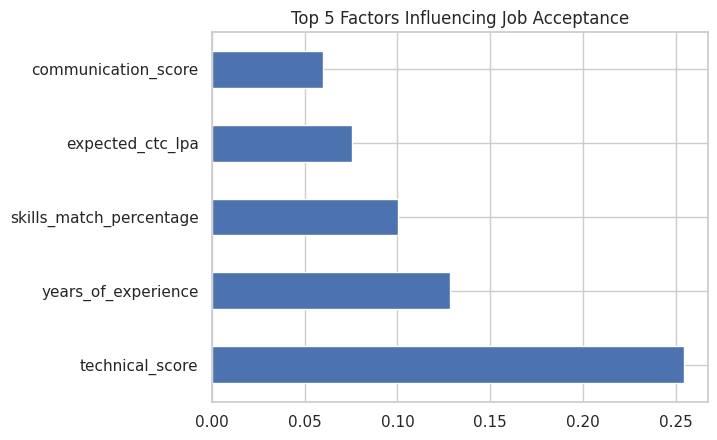

In [36]:
# Feature Importance
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.nlargest(5).plot(kind='barh')
plt.title('Top 5 Factors Influencing Job Acceptance')
plt.show()